# Лабораторная работа №2
## *Просодика*
## EDA: анализ пауз, слов, букв и гласных в корпусе RUSLAN
по курсу Синтез речи  
**направление:** Речевые технологии и машинное обучение   
**преподаватели:** Чирковский А.Д., Рыбин С.В.  
**выполнил:** Янкин Иван Ю.  
**группа:** М4221

Ноутбук отвечает на вопросы:
- какова средняя длительность паузы / слова / буквы / гласной;
- как распределены эти длительности (гистограммы);
- в каких местах корпуса появляются паузы и насколько они логичны;
- какие классы пауз наблюдаются (по длительности и по контексту).

In [1]:
import re
import csv
import glob
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True

DATA_PATH = 'data/RUSLAN_pause_metadata.csv'
ALIGN_DIR = '../../data/RUSLAN_align/v2/'
RANDOM_STATE = 42

## 1. Загрузка и общая проверка данных

In [2]:
df = pd.read_csv(DATA_PATH, sep='|', quoting=csv.QUOTE_NONE)
df = df[df.set == 'train'].copy()
print(df.shape)
df.head(10)

(196710, 8)


,label,duration,id,label_raw,is_last_word,is_pause_after,pause_duration,set
7,кого,0.43,000001_RUSLAN,Кого,0,1,0.030000,train
8,интересуют,0.69,000001_RUSLAN,интересуют,0,0,0.000000,train
9,признания,0.58,000001_RUSLAN,признания,0,0,0.000000,train
10,литературного,0.73,000001_RUSLAN,литературного,0,0,0.000000,train
11,неудачника,0.73,000001_RUSLAN,неудачника?,1,1,0.029909,train
12,что,0.33,000002_RUSLAN,Что,0,0,0.000000,train
13,поучительного,0.96,000002_RUSLAN,поучительного,0,0,0.000000,train
14,в,0.04,000002_RUSLAN,в,0,0,0.000000,train
15,его,0.44,000002_RUSLAN,его,0,1,0.030000,train
16,исповеди,0.50,000002_RUSLAN,исповеди?,1,1,0.034785,train


In [3]:

display(df.dtypes)
display(df.isna().sum())
print('Уникальных предложений (id):', df.id.nunique())
print('Строк train/test:')
display(df.set.value_counts())

label                 str
duration          float64
id                    str
label_raw             str
is_last_word        int64
is_pause_after      int64
pause_duration    float64
set                   str
dtype: object

label             0
duration          0
id                0
label_raw         0
is_last_word      0
is_pause_after    0
pause_duration    0
set               0
dtype: int64

Уникальных предложений (id): 17006
Строк train/test:


set
train    196710
Name: count, dtype: int64

**На что смотреть:** пропусков в `label`/`label_raw` нет (если есть, это признак сбоя alignment), доля `test` 20%.

## 2. Производные признаки: буквы, гласные, длительности

`duration` в таблице — это длительность слова (интервал из word-tier TextGrid). Чтобы оценить длительность буквы, нормируем длительность слова на число букв в нём; аналогично для гласных — на число гласных букв. грубая, но стандартная оценка; предполагает равномерное распределение времени внутри слова.

Более точная оценка длительности гласной — в п.6.

In [4]:
VOWELS = set('аоиеёэыуюя')

def clean_letters(label: str) -> str:
    if not isinstance(label, str):
        return ''
    return re.sub(r'[^а-яё]', '', label.lower())

df['letters'] = df.label.apply(clean_letters)
df['n_letters'] = df.letters.str.len()
df['n_vowels'] = df.letters.apply(lambda s: sum(c in VOWELS for c in s))

words = df[df.n_letters > 0].copy()
words['dur_per_letter'] = words.duration / words.n_letters
words = words[words.n_vowels > 0]
words['dur_per_vowel'] = words.duration / words.n_vowels

print('Слов с буквами:', len(words))
words[['label', 'duration', 'n_letters', 'n_vowels', 'dur_per_letter', 'dur_per_vowel']].head()

Слов с буквами: 188678


,label,duration,n_letters,n_vowels,dur_per_letter,dur_per_vowel
7,кого,0.43,4,2,0.107500,0.215000
8,интересуют,0.69,10,5,0.069000,0.138000
9,признания,0.58,9,4,0.064444,0.145000
10,литературного,0.73,13,6,0.056154,0.121667
11,неудачника,0.73,10,5,0.073000,0.146000


## 3. Средние длительности (пауза / слово / буква / гласная)

Для паузы усредняем по величине `pause_duration` только там, где пауза реально есть (`is_pause_after == 1`) — иначе среднее размажется нулями. Финальную паузу предложения не включаем — такие паузы это стык записанных файлов, а не элемент естественной речи.

In [5]:
pauses = df[(df.is_pause_after == 1) & (df.is_last_word == 0)]

summary = pd.DataFrame({
    'metric': ['pause_duration', 'word_duration', 'letter_duration (approx)', 'vowel_duration (approx)'],
    'mean_sec': [
        pauses.pause_duration.mean(),
        df.duration.mean(),
        words.dur_per_letter.mean(),
        words.dur_per_vowel.mean(),
    ],
    'median_sec': [
        pauses.pause_duration.median(),
        df.duration.median(),
        words.dur_per_letter.median(),
        words.dur_per_vowel.median(),
    ],
    'std_sec': [
        pauses.pause_duration.std(),
        df.duration.std(),
        words.dur_per_letter.std(),
        words.dur_per_vowel.std(),
    ],
})
summary

,metric,mean_sec,median_sec,std_sec
0,pause_duration,0.172454,0.110,0.162172
1,word_duration,0.400989,0.400,0.221756
2,letter_duration (approx),0.076520,0.070,0.031652
3,vowel_duration (approx),0.174732,0.164,0.071729


## 4. Гистограммы распределения длительностей
Длительности сильно скошены, поэтому смотрим и в линейном и в лог-масштабе по X

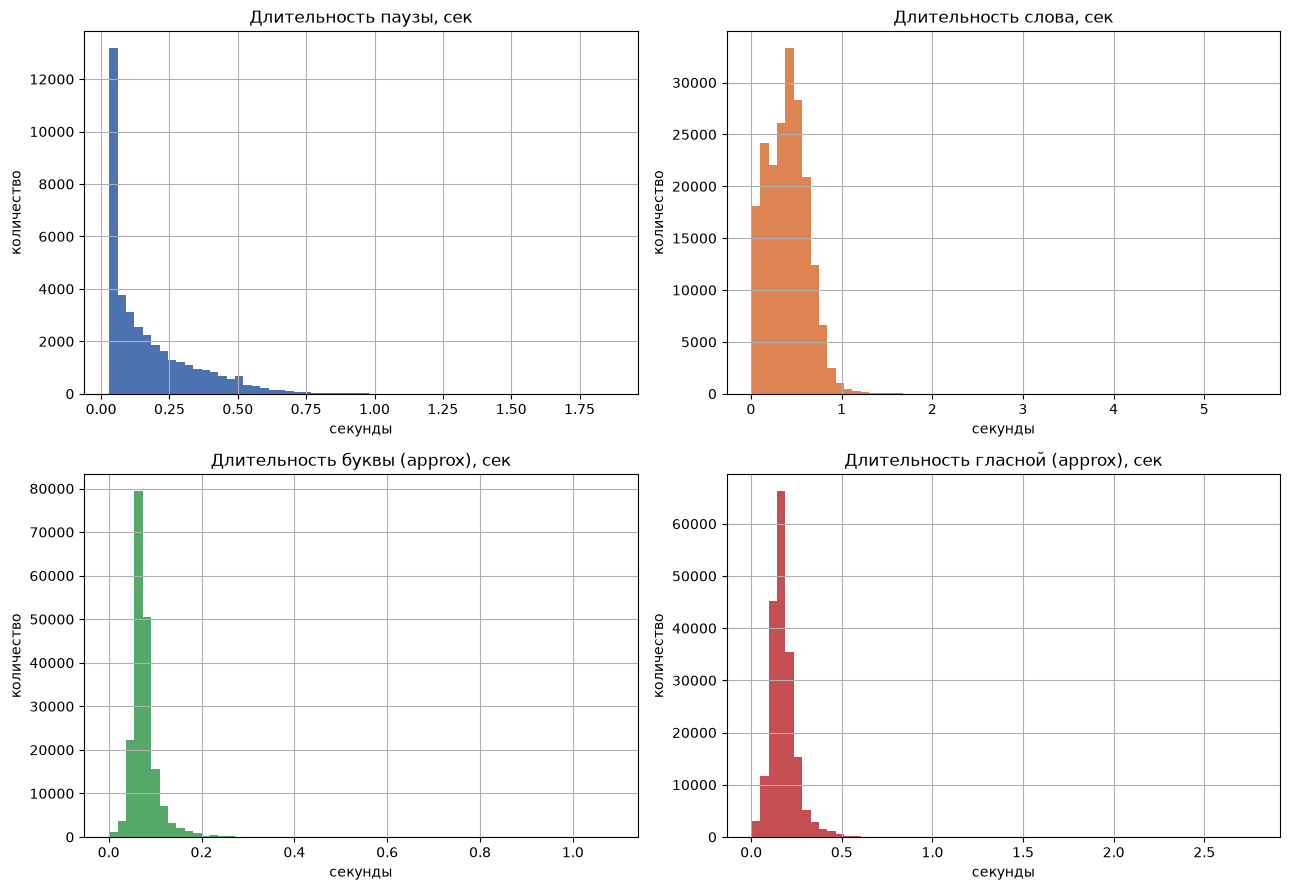

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].hist(pauses.pause_duration, bins=60, color='#4C72B0')
axes[0, 0].set_title('Длительность паузы, сек')

axes[0, 1].hist(df.duration, bins=60, color='#DD8452')
axes[0, 1].set_title('Длительность слова, сек')

axes[1, 0].hist(words.dur_per_letter, bins=60, color='#55A868')
axes[1, 0].set_title('Длительность буквы (approx), сек')

axes[1, 1].hist(words.dur_per_vowel, bins=60, color='#C44E52')
axes[1, 1].set_title('Длительность гласной (approx), сек')

for ax in axes.ravel():
    ax.set_xlabel('секунды')
    ax.set_ylabel('количество')

plt.tight_layout()
plt.show()

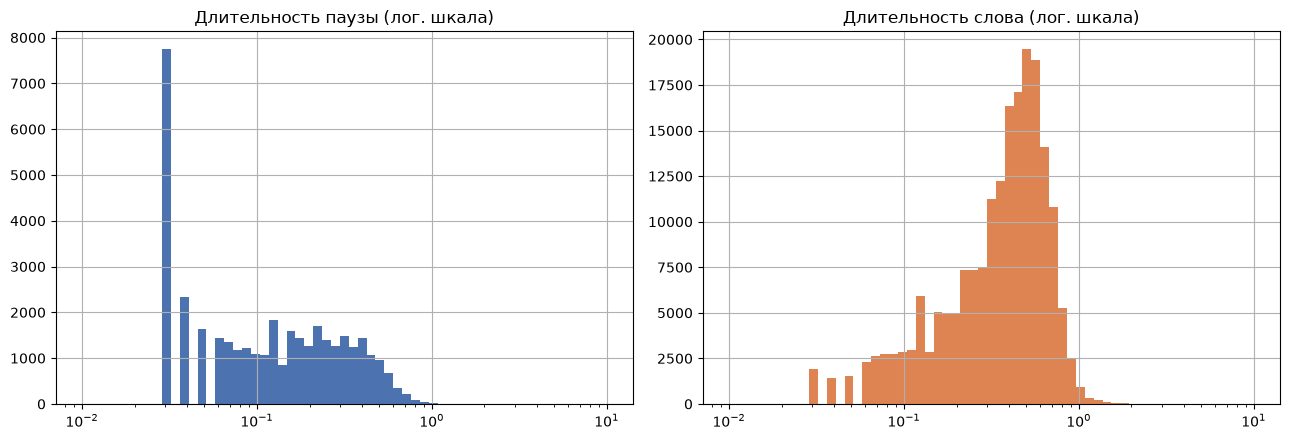

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(pauses.pause_duration.clip(lower=1e-3), bins=np.logspace(-2, 1, 60), color='#4C72B0')
axes[0].set_xscale('log')
axes[0].set_title('Длительность паузы (лог. шкала)')

axes[1].hist(df.duration.clip(lower=1e-3), bins=np.logspace(-2, 1, 60), color='#DD8452')
axes[1].set_xscale('log')
axes[1].set_title('Длительность слова (лог. шкала)')

plt.tight_layout()
plt.show()

**Вопросы к себе при разборе гистограмм:**
- Есть ли у паузы явная мультимодальность (несколько «горбов») — намёк на разные *классы* пауз (короткая между словами внутри фразы / средняя на запятой / длинная на точке или абзаце)? Разбираем в п. 5–6.
- Есть ли аномально длинные слова/паузы (хвост >1–2 сек) — стоит проверить их отдельно, возможно это сбои выравнивания, а не реальная просодика.
- Соответствует ли порядок величин ожиданиям (пауза обычно от ~0.05 до ~0.5–1 сек, гласная — десятки-сотни мс).

In [8]:
# проверка на выбросы: топ самых длинных пауз и слов — посмотреть на сами токены
print('Топ-15 самых длинных пауз:')
display(pauses.nlargest(15, 'pause_duration')[['id', 'label_raw', 'pause_duration']])

print('Топ-15 самых длинных слов:')
display(df.nlargest(15, 'duration')[['id', 'label_raw', 'duration']])

Топ-15 самых длинных пауз:


,id,label_raw,pause_duration
212793,019693_RUSLAN,"Слуцкого,",1.870000
230131,020966_RUSLAN,Я,1.630000
209434,019547_RUSLAN,Генри,1.590000
187562,018117_RUSLAN,в,1.560000
211523,019658_RUSLAN,плана—,1.530000
204336,019282_RUSLAN,частью,1.430000
211660,019662_RUSLAN,кодекса,1.370000
225899,020622_RUSLAN,Блюхер.,1.270000
58983,007923_RUSLAN,кабинете.,1.240000
227853,020779_RUSLAN,Аврора».,1.230000


Топ-15 самых длинных слов:


,id,label_raw,duration
185569,017964_RUSLAN,Ясперс!,5.558300
198846,018993_RUSLAN,претензии,3.510000
192756,018538_RUSLAN,Чернышевский,3.230000
203837,019252_RUSLAN,пренебрегает,2.940000
132314,013808_RUSLAN,фантазии.,2.928209
15862,002838_RUSLAN,распространении,2.750000
69391,008798_RUSLAN,побаивались,2.670000
193086,018557_RUSLAN,интересовать.,2.640000
7272,001258_RUSLAN,Мастера,2.560000
205327,019349_RUSLAN,"человека,",2.540000


## 5. Где появляются паузы и насколько они логичны

Гипотеза: место и длительность паузы сильно определяются **пунктуацией**, идущей сразу после слова (она уже находится в `label_raw`), и **позицией слова в предложении**.

In [9]:
PUNCT_MAP = [
    (r'\.\.\.$|…$', 'многоточие'),
    (r'[.]$', 'точка'),
    (r'[,]$', 'запятая'),
    (r'[;]$', 'точка с запятой'),
    (r'[:]$', 'двоеточие'),
    (r'[!]$', 'восклицательный'),
    (r'[?]$', 'вопросительный'),
    (r'[—-]$', 'тире'),
    (r'[)\]»"]$', 'закрывающая скобка/кавычка'),
]

def punct_class(label_raw: str) -> str:
    if not isinstance(label_raw, str):
        return 'нет'
    s = label_raw.strip()
    for pattern, name in PUNCT_MAP:
        if re.search(pattern, s):
            return name
    return 'нет' if re.search(r'[а-яёa-z]$', s.lower()) else 'прочее'

work = df[df.is_last_word == 0].copy()
work['punct'] = work.label_raw.apply(punct_class)

by_punct = work.groupby('punct').agg(
    n_tokens=('label', 'size'),
    pause_rate=('is_pause_after', 'mean'),
    mean_pause_dur=('pause_duration', lambda s: s[s > 0].mean()),
).sort_values('pause_rate', ascending=False)
by_punct

,n_tokens,pause_rate,mean_pause_dur
punct,,,
точка с запятой,1,1.000000,0.720000
точка,10136,0.953532,0.223713
многоточие,1843,0.930005,0.205578
восклицательный,614,0.925081,0.217518
вопросительный,981,0.893986,0.216682
закрывающая скобка/кавычка,420,0.742857,0.237756
запятая,14502,0.548407,0.163429
тире,8267,0.537438,0.197574
прочее,1253,0.535515,0.204590


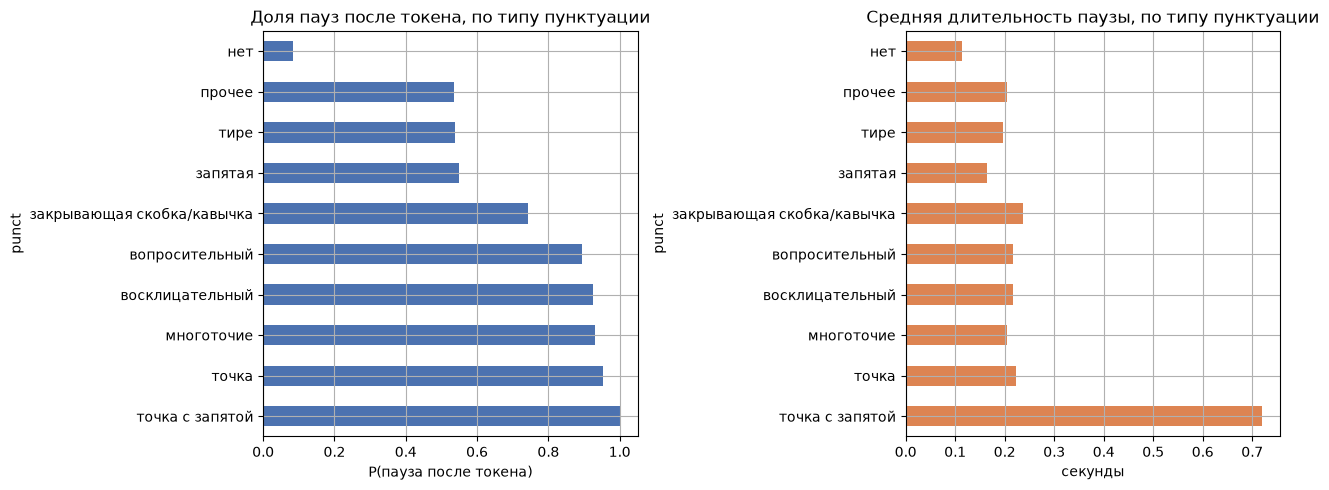

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

by_punct.pause_rate.plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('Доля пауз после токена, по типу пунктуации')
axes[0].set_xlabel('P(пауза после токена)')

by_punct.mean_pause_dur.plot(kind='barh', ax=axes[1], color='#DD8452')
axes[1].set_title('Средняя длительность паузы, по типу пунктуации')
axes[1].set_xlabel('секунды')

plt.tight_layout()
plt.show()

**Интерпретация:** если после точки/многоточия/вопросительного и восклицательного знаков пауза почти всегда есть и она заметно длиннее, чем после запятой, а после токенов без пунктуации пауза скорее исключение — разметка логична и согласуется с лингвистической интуицией (границы синтагм и предложений маркируются длинными паузами, границы слов внутри фразы — нет или короткими). Если наблюдается обратное (например, много длинных пауз без всякой пунктуации, или наоборот — отсутствие пауз после точек) — это повод заподозрить проблемы выравнивания в соответствующих файлах, и явно написать об этом в отчёте (п.  выводы).

### 5.1 Позиция в предложении

Проверяем, зависит ли вероятность паузы от относительной позиции слова в предложении (начало / середина / конец фразы) — это косвенно покажет, действительно ли паузы расставлены по смыслу, а не случайно.

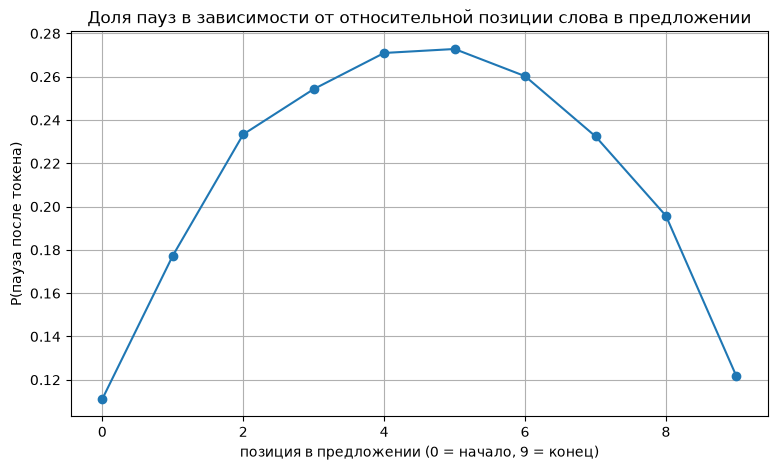

In [11]:
work['pos_in_sentence'] = work.groupby('id').cumcount()
sent_len = work.groupby('id').size().rename('sent_len')
work = work.merge(sent_len, on='id')
work['rel_pos'] = work.pos_in_sentence / work.sent_len.clip(lower=1)
work['rel_pos_bin'] = pd.cut(work.rel_pos, bins=10, labels=False)

pos_curve = work.groupby('rel_pos_bin').is_pause_after.mean()
pos_curve.plot(marker='o')
plt.title('Доля пауз в зависимости от относительной позиции слова в предложении')
plt.xlabel('позиция в предложении (0 = начало, 9 = конец)')
plt.ylabel('P(пауза после токена)')
plt.show()

### 5.2 Простые корреляции

Смотрим, связана ли длина/длительность слова с тем, что за ним следует пауза и с её длительностью.

In [12]:
num_cols = ['duration', 'n_letters', 'is_pause_after', 'pause_duration', 'rel_pos']
corr_df = work.merge(df[['n_letters']], left_index=True, right_index=True, how='left', suffixes=('', '_dup')) if False else work
corr = work[['duration', 'is_pause_after', 'pause_duration', 'rel_pos']].corr()
corr

,duration,is_pause_after,pause_duration,rel_pos
duration,1.000000,0.393490,0.259160,0.025045
is_pause_after,0.393490,1.000000,0.686428,0.044647
pause_duration,0.259160,0.686428,1.000000,0.050237
rel_pos,0.025045,0.044647,0.050237,1.000000


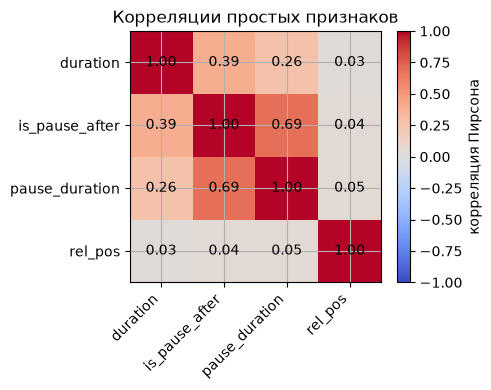

In [13]:
plt.figure(figsize=(5, 4))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(range(len(corr)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr)), corr.columns)
plt.colorbar(label='корреляция Пирсона')
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')
plt.title('Корреляции простых признаков')
plt.tight_layout()
plt.show()

## 6. Классы пауз

Проверяем гипотезу о нескольких классах пауз двумя способами:
1. Визуально — по гистограмме `pause_duration` (п. 4) и по группировке через пунктуацию (п. 5) — пунктуация уже сама по себе задаёт содержательные классы.
2. Формально — кластеризацией `pause_duration` (KMeans на логарифме длительности).

In [14]:
from sklearn.cluster import KMeans

pause_rows = work[(work.is_pause_after == 1) & (work.pause_duration > 0)].copy()
X = np.log(pause_rows.pause_duration.values).reshape(-1, 1)

N_CLUSTERS = 3  # по смыслу (короткая/средняя/длинная)
km = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10).fit(X)
pause_rows['duration_cluster'] = km.labels_

order = pause_rows.groupby('duration_cluster').pause_duration.mean().sort_values().index
remap = {old: new for new, old in enumerate(order)}
pause_rows['duration_cluster'] = pause_rows.duration_cluster.map(remap)

display(pause_rows.groupby('duration_cluster').pause_duration.agg(['count', 'mean', 'min', 'max']))

,count,mean,min,max
duration_cluster,,,,
0,13176,0.037549,0.029998,0.060002
1,12939,0.125423,0.069999,0.200001
2,11999,0.371309,0.209999,1.870000


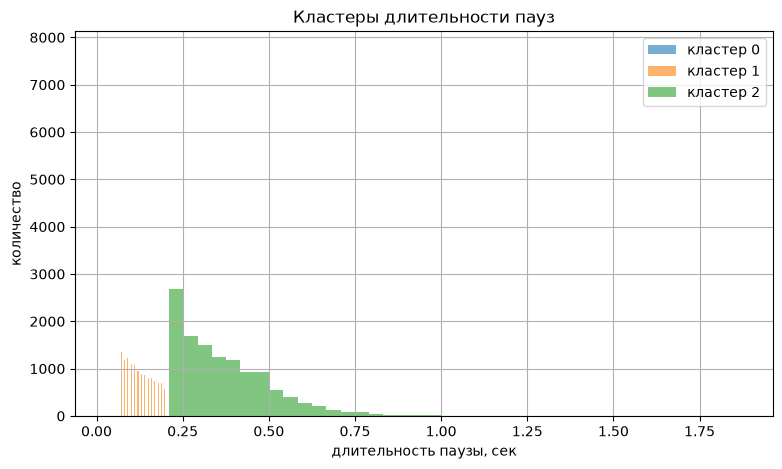

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
for c in sorted(pause_rows.duration_cluster.unique()):
    subset = pause_rows[pause_rows.duration_cluster == c]
    ax.hist(subset.pause_duration, bins=40, alpha=0.6, label=f'кластер {c}')
ax.set_xlabel('длительность паузы, сек')
ax.set_ylabel('количество')
ax.set_title('Кластеры длительности пауз')
ax.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Работаем ТОЛЬКО со второй таблицей (назовем её labels_df)
# Добавляем длину слова прямо сюда, чтобы не делать merge
labels_df = work.copy()
labels_df["calculated_word_len"] = labels_df["label_raw"].astype(str).str.len()

# Выделяем строки, где реально есть пауза
pause_mask = (labels_df.is_pause_after == 1) & (labels_df.pause_duration > 0)

# ВАЖНО: punct_class находится в первой таблице. 
# Но строки без пунктуации в таблице таргетов — это те, у которых в текстовом label_raw 
# на конце НЕТ знаков препинания (.,!?), либо можно временно подтянуть только ОДНУ эту колонку:
# punct_class_series = features_df.set_index('id')['punct_class']
# labels_df['punct_class'] = labels_df['id'].map(punct_class_series)

# Способ 1: Если punct_class всё же хочется взять в явном виде, подтянем ТОЛЬКО его (без полного merge):
labels_df["punct_class"] = labels_df["id"].map(
    features_df.set_index("id")["punct_class"]
)

none_class_mask = labels_df.punct_class == "none"

# ==========================================
# 1. Поиск 95-го перцентиля для класса 'none'
# ==========================================
none_pauses = labels_df[pause_mask & none_class_mask]
threshold_95 = np.percentile(none_pauses.pause_duration, 95)
print(f"📌 95-й перцентиль для класса 'none': {threshold_95:.3f} сек.")

# ==========================================
# 2. Поиск аномалий у коротких слов (1-2 буквы)
# ==========================================
ANOMALY_TIME = 1.5
short_word_noise_mask = (
    pause_mask
    & (labels_df.calculated_word_len <= 2)
    & (labels_df.pause_duration > ANOMALY_TIME)
)

# ==========================================
# 3. Фильтрация и получение списка "чистых" ID
# ==========================================
none_outliers_mask = (
    pause_mask & none_class_mask & (labels_df.pause_duration > threshold_95)
)
total_noise_mask = short_word_noise_mask | none_outliers_mask

# Вместо пересборки огромной таблицы, мы просто получаем ID «грязных» строк из train
noise_ids_to_drop = labels_df[
    (labels_df["set"] == "train") & total_noise_mask
]["id"].unique()

print(f"❌ Количество шумных ID, которые мы выкинем: {len(noise_ids_to_drop)}")

# Теперь вы можете легко отфильтровать обе исходные таблицы по этому списку ID:
# features_train_clean = features_df[~features_df.id.isin(noise_ids_to_drop)]
# labels_train_clean = labels_df[~labels_df.id.isin(noise_ids_to_drop)]


NameError: name 'features_df' is not defined

In [37]:
cross = pd.crosstab(pause_rows.punct, pause_rows.duration_cluster, normalize='index')
cross

duration_cluster,0,1,2
punct,,,
вопросительный,0.176739,0.380844,0.442417
восклицательный,0.177817,0.382042,0.440141
закрывающая скобка/кавычка,0.176282,0.323718,0.500000
запятая,0.386269,0.332579,0.281152
многоточие,0.196033,0.388565,0.415403
нет,0.536608,0.305626,0.157767
прочее,0.277198,0.332340,0.390462
тире,0.261985,0.353365,0.384650
точка,0.177548,0.366580,0.455872


## 7. Длительность гласных на уровне фонем (точная оценка)

Оценка `dur_per_vowel` в п. 2–3 — грубая (длительность слова, поделённая на число гласных букв). Чтобы получить честную длительность именно гласного *звука*, читаем phone-tier из тех же `.TextGrid` напрямую (используем `read_text_grids` из `prepare_training_data.py`).

In [ ]:
sys.path.append('.')
from prepare_training_data import read_text_grids

RUSLAN_META = '../../data/metadata_RUSLAN_22200_normalized.csv'
SAMPLE_N = None  # None = весь корпус

ruslan_meta = pd.read_csv(RUSLAN_META, sep='|', names=['id', 'raw', 'nrm'], quoting=csv.QUOTE_NONE)
if SAMPLE_N:
    ruslan_meta = ruslan_meta.sample(SAMPLE_N, random_state=RANDOM_STATE)

_, phn_df, _ = read_text_grids(ruslan_meta, ALIGN_DIR)
phn_df = phn_df[phn_df.label != '<SIL>']
print(phn_df.shape)
phn_df.head()

 14%|█▍        | 2983/21256 [00:51<05:10, 58.80it/s]

In [ ]:
print('Топ-40 самых частых фонемных меток:')
display(phn_df.label.value_counts().head(40))

Топ-40 самых частых фонемных меток:


label
ɪ      98266
ə      93876
ɐ      66886
t̪     57181
a      56735
j      48764
n̪     42697
e      41864
s̪     39433
r      38823
o      38801
i      37997
ɨ      37686
v      36602
k      34604
ɫ      33510
m      29251
ʎ      28268
ɲ      27479
p      26748
ʊ      24568
tʲ     23299
sʲ     21609
d̪     21298
rʲ     19344
z̪     19021
u      17449
b      15140
spn    14627
tɕ     14468
ʂ      13573
dʲ     12712
ɡ      12119
ʐ      11984
f      11404
vʲ     11362
mʲ     10817
x       9794
c       8273
ɛ       6292
Name: count, dtype: int64

In [ ]:
VOWEL_PHONES = {
    'a', 'ɐ', 'e', 'ɛ', 'i', 'ɪ', 'o', 'u', 'ʊ', 'ɨ', 'ə',
    'a0', 'a1', 'ɐ0', 'ɐ1',
    'e0', 'e1', 'ɛ0', 'ɛ1',
    'i0', 'i1', 'ɪ0', 'ɪ1',
    'o0', 'o1',
    'u0', 'u1', 'ʊ0', 'ʊ1',
    'ɨ0', 'ɨ1',
    'ə0', 'ə1',
}

phn_df['is_vowel'] = phn_df.label.str.lower().isin(VOWEL_PHONES)
print('Доля фонем, отмеченных как гласные:', phn_df.is_vowel.mean().round(3))

vowel_phones = phn_df[phn_df.is_vowel]
print('Точная средняя длительность гласного звука, сек:', vowel_phones.duration.mean().round(4))
print('Медиана:', vowel_phones.duration.median().round(4))

Доля фонем, отмеченных как гласные: 0.411
Точная средняя длительность гласного звука, сек: 0.058
Медиана: 0.05


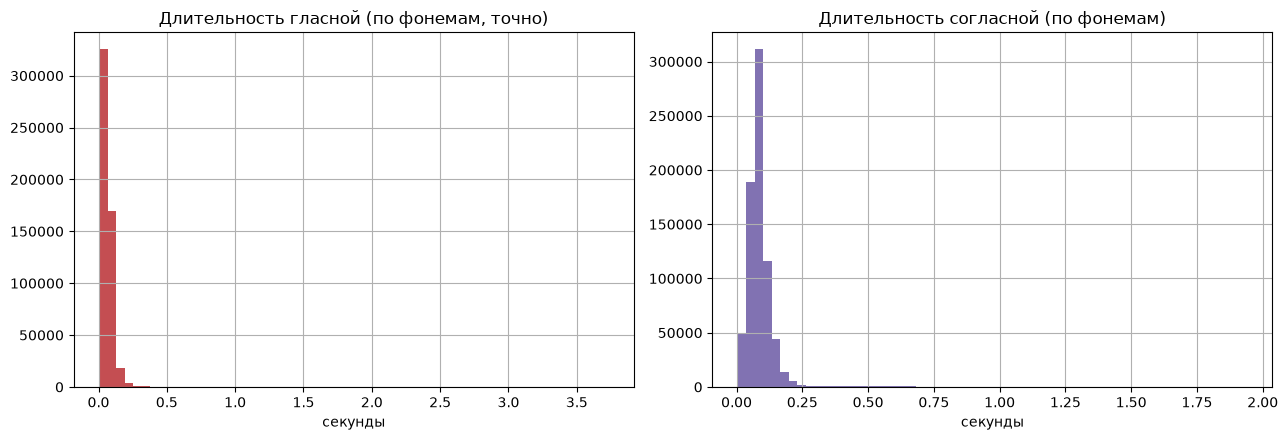

Сравнение с грубой оценкой из п. 3 (duration слова / число гласных букв): 0.1747
Точная фонемная оценка: 0.058


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(vowel_phones.duration, bins=60, color='#C44E52')
axes[0].set_title('Длительность гласной (по фонемам, точно)')
axes[0].set_xlabel('секунды')

axes[1].hist(phn_df[~phn_df.is_vowel].duration, bins=60, color='#8172B2')
axes[1].set_title('Длительность согласной (по фонемам)')
axes[1].set_xlabel('секунды')
plt.tight_layout()
plt.show()

print('Сравнение с грубой оценкой из п. 3 (duration слова / число гласных букв):', round(words.dur_per_vowel.mean(), 4))
print('Точная фонемная оценка:', round(vowel_phones.duration.mean(), 4))

Ожидаемо, что грубая словная оценка будет систематически смещена относительно точной фонемной — слово делится не поровну между гласными и согласными.

## 8. Итоговые выводы

- Медиана 0.11 с, среднее 0.172 с — распределение сильно скошено вправо (std 0.162 — почти как сама медиана). Значит, точечная модель среднее по всему корпусу даст плохой MAE на длинных паузах; нужна дифференциация по классам.
- Пунктуация — сильный, но неполный сигнал для места паузы:

| Класс пунктуации | P(пауза) | Вывод |
|---|---|---|
| точка / многоточие / ?/! / закр. скобка | 0.75–0.95 | почти детерминированный триггер паузы |
| запятая / тире / «прочее» | 0.52–0.55 | не жёсткое правило — здесь одной пунктуации мало, нужны доп. признаки (длина, соседние слова) |
| нет пунктуации | 0.084 | пауза — исключение, но... |
- примерно треть (≈31%) всех пауз в корпусе вообще не имеет пунктуационного маркера. чистого rule-based по пунктуации, видимо, будет недостаточно; нужен хотя бы простой классификатор с доп. признаками (длина слова/предложения, POS, позиция) поверх пунктуационной эвристики
- Позиция в предложении — не линейная, а колоколообразная зависимость. если просто подать rel_pos как линейный признак в логрег, сигнал потеряется. для линейных моделей стоит либо забинировать позицию, либо не полагаться на неё напрямую.
- Классы пауз по длительности соотносятся с пунктуацией в среднем, но разделение далеко не чистое (например, «точка» распределена по трём кластерам, а не сконцентрирована в одном). 
- Выбросы - паузы у имён собственных/цитат
- Точная длительность гласной (0.058 с) против грубой оценки (0.1747 с) подтверждает, что упрощённая оценка «длительность слова / число гласных букв» завышает истинную длительность звука примерно в 3 раза